# 03 - Treino CNN1D (PyTorch)

CNN1D com embeddings, filtros múltiplos e features estilométricas.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Optuna com 20 trials


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

from src.data_processing import clean_text_sequences
from src.features import TextDataset, Vocabulary, load_glove_embeddings, texts_to_sequences
from src.hyperopt import create_study, study_results_dataframe, suggest_params
from src.models_pytorch.cnn1d import CNN1DClassifier
from src.stylometric_features import StylometricFeaturesExtractor


In [3]:
# Configuração
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
N_TRIALS = 20
MAX_LEN = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Device: {DEVICE}')


Device: cuda


## 1. Carregamento de Dados

In [4]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text_sequences)
    return df


df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')


Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
Train: 2566 amostras
  Labels: {'Human': 567, 'Meta': 555, 'Google': 525, 'Anthropic': 488, 'OpenAI': 431}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


## 2. Funções de Treino

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        if len(batch) == 3:
            seqs, style_batch, labs = batch
            style_batch = style_batch.to(device)
        else:
            seqs, labs = batch
            style_batch = None
        seqs, labs = seqs.to(device), labs.to(device)
        optimizer.zero_grad()
        out = model(seqs, style_batch)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labs)
        correct += (out.argmax(dim=1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs, style_batch)
            loss = criterion(out, labs)
            total_loss += loss.item() * len(labs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return total_loss / total, correct / total


def train_cnn(params, train_texts, train_labels, val_texts, val_labels, train_style, val_style, device):
    vocab = Vocabulary(max_words=params['vocab_size'])
    vocab.fit(list(train_texts))

    X_train_seq = texts_to_sequences(list(train_texts), vocab, max_len=MAX_LEN)
    X_val_seq = texts_to_sequences(list(val_texts), vocab, max_len=MAX_LEN)

    pretrained_embeddings = None
    glove_path = f"../data/embeddings/glove.6B.{params['embedding_dim']}d.txt"
    if os.path.exists(glove_path):
        pretrained_embeddings = load_glove_embeddings(
            glove_path, vocab, embedding_dim=params['embedding_dim']
        )
    else:
        print(f"Warning: {glove_path} not found, training embeddings from scratch")

    model = CNN1DClassifier(
        vocab_size=len(vocab),
        embedding_dim=params['embedding_dim'],
        n_filters=params['n_filters'],
        filter_sizes=params['filter_sizes'],
        output_dim=NUM_CLASSES,
        dropout=params['dropout'],
        pretrained_embeddings=pretrained_embeddings,
        n_style_features=train_style.shape[1],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=params['lr'],
    )

    train_ds = TextDataset(X_train_seq, train_labels, train_style)
    val_ds = TextDataset(X_val_seq, val_labels, val_style)
    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'])

    best_val_acc = -1.0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(params['epochs']):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model, val_dl, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    train_time = time.time() - t0
    return model, vocab, best_val_acc, max(history['train_acc']), history, train_time


def evaluate_external_cnn(model, vocab, texts, labels, batch_size, device, style_features=None):
    X_seq = texts_to_sequences(list(texts), vocab, max_len=MAX_LEN)
    ds = TextDataset(X_seq, labels, style_features)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dl:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs, style_batch)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return correct / total


def get_predictions_cnn(model, vocab, texts, labels, batch_size, device, style_features=None):
    X_seq = texts_to_sequences(list(texts), vocab, max_len=MAX_LEN)
    ds = TextDataset(X_seq, labels, style_features)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in dl:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            out = model(seqs.to(device), style_batch)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labs.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


def full_evaluation_cnn(model, vocab, texts, labels, name, batch_size, device, style_features=None):
    probs, labels = get_predictions_cnn(model, vocab, texts, labels, batch_size, device, style_features)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()
    plt.show()
    return probs, labels


## 3. Espaço de Busca e Optuna

In [6]:
# Features estilométricas
style_extractor = StylometricFeaturesExtractor()
X_train_style_all = style_extractor.fit_transform(list(df_train['Text']))
X_val1_style = style_extractor.transform(list(df_val1['Text']))
X_val2_style = style_extractor.transform(list(df_val2['Text']))

style_mean = X_train_style_all.mean(axis=0)
style_std = X_train_style_all.std(axis=0) + 1e-8
X_train_style_all = (X_train_style_all - style_mean) / style_std
X_val1_style = (X_val1_style - style_mean) / style_std
X_val2_style = (X_val2_style - style_mean) / style_std

train_idx, val_idx = train_test_split(
    np.arange(len(df_train)),
    test_size=0.2,
    random_state=SEED,
    stratify=df_train['label_id'].values,
)

train_texts = df_train['text_clean'].iloc[train_idx].tolist()
val_texts = df_train['text_clean'].iloc[val_idx].tolist()
y_train = df_train['label_id'].iloc[train_idx].values.astype(np.int64)
y_val = df_train['label_id'].iloc[val_idx].values.astype(np.int64)
X_train_style = X_train_style_all[train_idx]
X_val_style = X_train_style_all[val_idx]

search_space = {
    'vocab_size': [1000, 2000, 5000],
    'embedding_dim': [50, 100],
    'n_filters': [32, 64, 128],
    'filter_sizes': [[2, 3], [2, 3, 4], [1, 2, 3]],
    'dropout': [0.2, 0.3, 0.45],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64],
    'epochs': [15, 30],
}

print('Opções por parâmetro:')
for k, v in search_space.items():
    print(f'  {k}: {len(v)} opções')

print(f'Train interno: {len(train_texts)}')
print(f'Val interno: {len(val_texts)}')
print(f'Val1 externo: {len(df_val1)}')
print(f'Val2 externo: {len(df_val2)}')


Opções por parâmetro:
  vocab_size: 3 opções
  embedding_dim: 2 opções
  n_filters: 3 opções
  filter_sizes: 3 opções
  dropout: 3 opções
  lr: 2 opções
  batch_size: 2 opções
  epochs: 2 opções
Train interno: 2052
Val interno: 514
Val1 externo: 125
Val2 externo: 100


In [7]:
def objective(trial):
    params = suggest_params(trial, search_space)

    print(
        f"[Trial {trial.number}] vocab={params['vocab_size']} emb={params['embedding_dim']} "
        f"filters={params['n_filters']} kernels={params['filter_sizes']} "
        f"drop={params['dropout']} lr={params['lr']} bs={params['batch_size']} epochs={params['epochs']}"
    )

    model, vocab, val_acc, train_acc, history, train_time = train_cnn(
        params,
        train_texts,
        y_train,
        val_texts,
        y_val,
        X_train_style,
        X_val_style,
        DEVICE,
    )

    val1_acc = evaluate_external_cnn(
        model, vocab, df_val1['text_clean'].tolist(), df_val1['label_id'].values,
        params['batch_size'], DEVICE, style_features=X_val1_style
    )
    val2_acc = evaluate_external_cnn(
        model, vocab, df_val2['text_clean'].tolist(), df_val2['label_id'].values,
        params['batch_size'], DEVICE, style_features=X_val2_style
    )

    trial.set_user_attr('internal_val', val_acc)
    trial.set_user_attr('train_acc', train_acc)
    trial.set_user_attr('val1_acc', val1_acc)
    trial.set_user_attr('val2_acc', val2_acc)
    trial.set_user_attr('train_time', train_time)

    print(f"  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)")
    return val_acc


study = create_study(direction='maximize', study_name='cnn1d_pytorch_optuna', seed=SEED)
study.optimize(objective, n_trials=N_TRIALS)

results_df = study_results_dataframe(study)
results_df = results_df[results_df['state'] == 'COMPLETE'].copy()
results_df = results_df.sort_values('internal_val', ascending=False).reset_index(drop=True)

best_trial = study.best_trial
best_params = best_trial.params.copy()
best_internal_val = best_trial.value

print('\n=== Top 5 Modelos (por internal_val) ===')
print(results_df.head(5)[[
    'trial', 'vocab_size', 'embedding_dim', 'n_filters', 'filter_sizes',
    'dropout', 'lr', 'batch_size', 'epochs', 'internal_val', 'val1_acc', 'val2_acc'
]].to_string(index=False))


[Trial 0] vocab=2000 emb=50 filters=128 kernels=[2, 3, 4] drop=0.2 lr=0.0005 bs=64 epochs=15


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [2, 3] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [2, 3, 4] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [1, 2, 3] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)


  -> internal=0.8463 | val1=0.4800 | val2=0.5100 (7.0s)
[Trial 1] vocab=1000 emb=100 filters=32 kernels=[1, 2, 3] drop=0.45 lr=0.001 bs=32 epochs=15


/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [2, 3] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [2, 3, 4] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/src/hyperopt.py:46: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [1, 2, 3] which is of type list.
  params[name] = trial.suggest_categorical(name, spec)


GloVe: 999/1002 palavras encontradas (99.7%)
  -> internal=0.9066 | val1=0.4320 | val2=0.5300 (4.1s)
[Trial 2] vocab=2000 emb=50 filters=32 kernels=[1, 2, 3] drop=0.3 lr=0.0005 bs=64 epochs=30
  -> internal=0.8852 | val1=0.4720 | val2=0.5700 (6.9s)
[Trial 3] vocab=5000 emb=50 filters=128 kernels=[2, 3, 4] drop=0.45 lr=0.0005 bs=32 epochs=15
  -> internal=0.8716 | val1=0.4880 | val2=0.5400 (5.6s)
[Trial 4] vocab=1000 emb=100 filters=64 kernels=[2, 3] drop=0.3 lr=0.001 bs=32 epochs=30
GloVe: 999/1002 palavras encontradas (99.7%)
  -> internal=0.9475 | val1=0.4640 | val2=0.5600 (7.0s)
[Trial 5] vocab=2000 emb=100 filters=128 kernels=[1, 2, 3] drop=0.3 lr=0.0005 bs=32 epochs=15
GloVe: 1998/2002 palavras encontradas (99.8%)
  -> internal=0.9125 | val1=0.4800 | val2=0.4900 (4.9s)
[Trial 6] vocab=2000 emb=100 filters=128 kernels=[2, 3, 4] drop=0.45 lr=0.001 bs=64 epochs=30
GloVe: 1998/2002 palavras encontradas (99.8%)
  -> internal=0.9280 | val1=0.4960 | val2=0.4600 (10.3s)
[Trial 7] vocab=10

## 4. Resultados

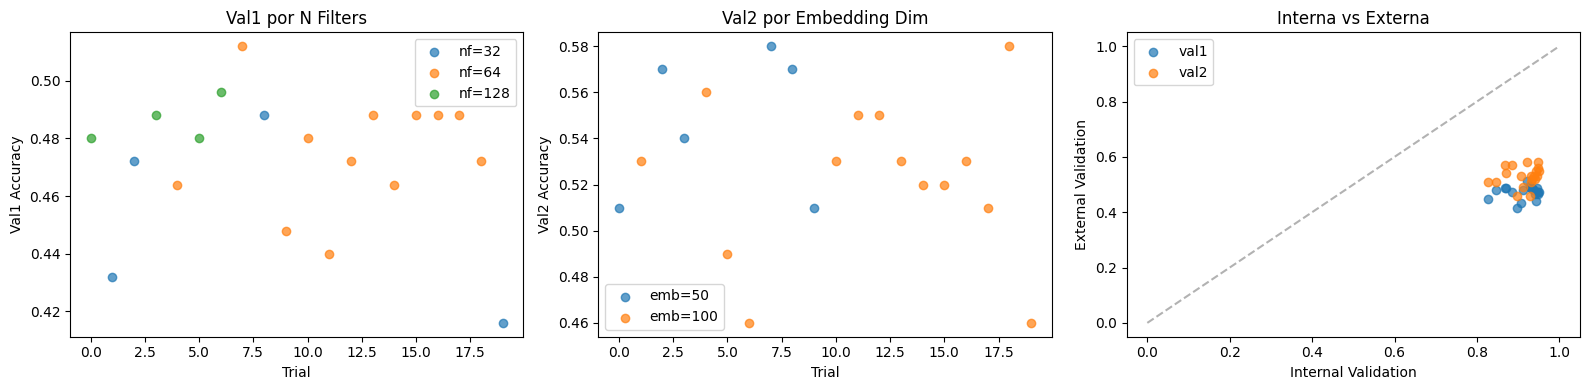

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for n_filters in sorted(results_df['n_filters'].unique()):
    mask = results_df['n_filters'] == n_filters
    axes[0].scatter(results_df[mask]['trial'], results_df[mask]['val1_acc'], label=f'nf={n_filters}', alpha=0.7)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 por N Filters')
axes[0].legend()

for emb in sorted(results_df['embedding_dim'].unique()):
    mask = results_df['embedding_dim'] == emb
    axes[1].scatter(results_df[mask]['trial'], results_df[mask]['val2_acc'], label=f'emb={emb}', alpha=0.7)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 por Embedding Dim')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Interna vs Externa')
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Avaliação Detalhada do Melhor Modelo

In [9]:
print('=== Melhor Modelo CNN1D ===')
for key, value in best_params.items():
    print(f'{key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')

best_model, best_vocab, _, _, best_history, _ = train_cnn(
    best_params,
    train_texts,
    y_train,
    val_texts,
    y_val,
    X_train_style,
    X_val_style,
    DEVICE,
)


=== Melhor Modelo CNN1D ===
vocab_size: 1000
embedding_dim: 100
n_filters: 64
filter_sizes: [2, 3]
dropout: 0.2
lr: 0.001
batch_size: 32
epochs: 30
Best Internal Validation Accuracy: 0.9494
GloVe: 999/1002 palavras encontradas (99.7%)



=== Val1 (exemplos) ===
Accuracy: 0.4800

              precision    recall  f1-score   support

   Anthropic       0.45      0.22      0.29        23
      Google       0.25      0.38      0.30        16
       Human       0.61      0.85      0.71        52
        Meta       0.67      0.12      0.20        17
      OpenAI       0.20      0.18      0.19        17

    accuracy                           0.48       125
   macro avg       0.44      0.35      0.34       125
weighted avg       0.49      0.48      0.44       125



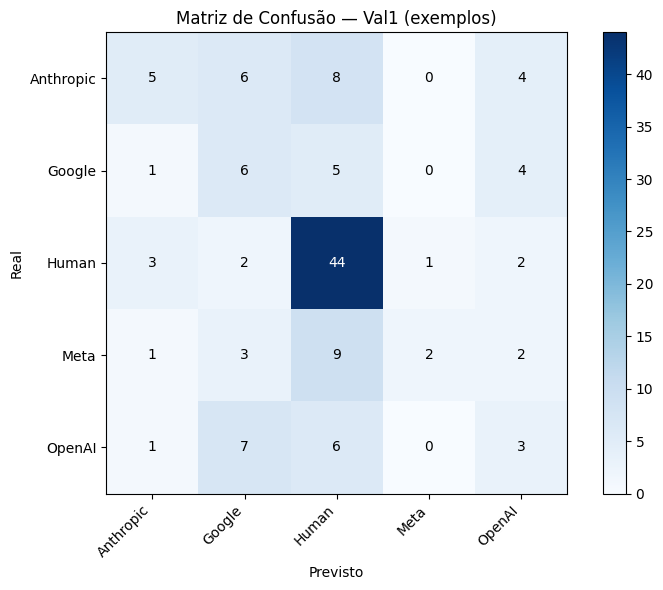


=== Val2 (subm1) ===
Accuracy: 0.5300

              precision    recall  f1-score   support

   Anthropic       0.36      0.24      0.29        17
      Google       0.60      0.53      0.56        17
       Human       0.54      0.91      0.68        34
        Meta       1.00      0.28      0.43        18
      OpenAI       0.33      0.29      0.31        14

    accuracy                           0.53       100
   macro avg       0.57      0.45      0.45       100
weighted avg       0.58      0.53      0.50       100



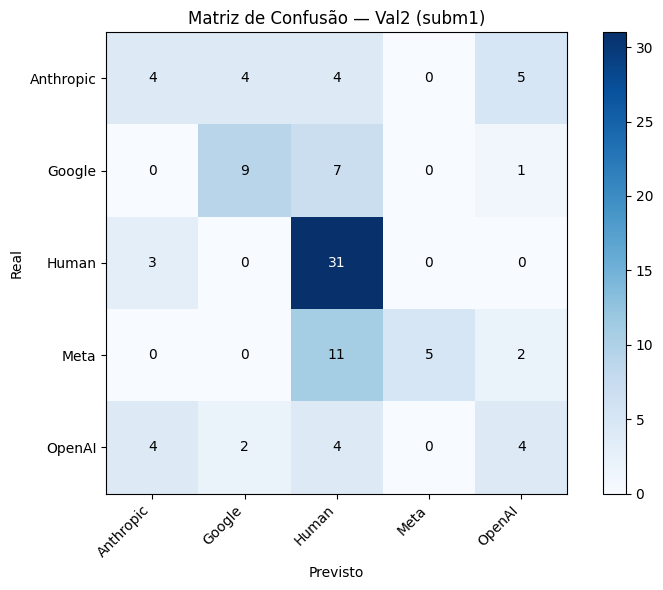

In [10]:
probs_val1, labels_val1 = full_evaluation_cnn(
    best_model,
    best_vocab,
    df_val1['text_clean'].tolist(),
    df_val1['label_id'].values,
    'Val1 (exemplos)',
    best_params['batch_size'],
    DEVICE,
    style_features=X_val1_style,
)

probs_val2, labels_val2 = full_evaluation_cnn(
    best_model,
    best_vocab,
    df_val2['text_clean'].tolist(),
    df_val2['label_id'].values,
    'Val2 (subm1)',
    best_params['batch_size'],
    DEVICE,
    style_features=X_val2_style,
)


## 6. Curva ROC (Macro Average)

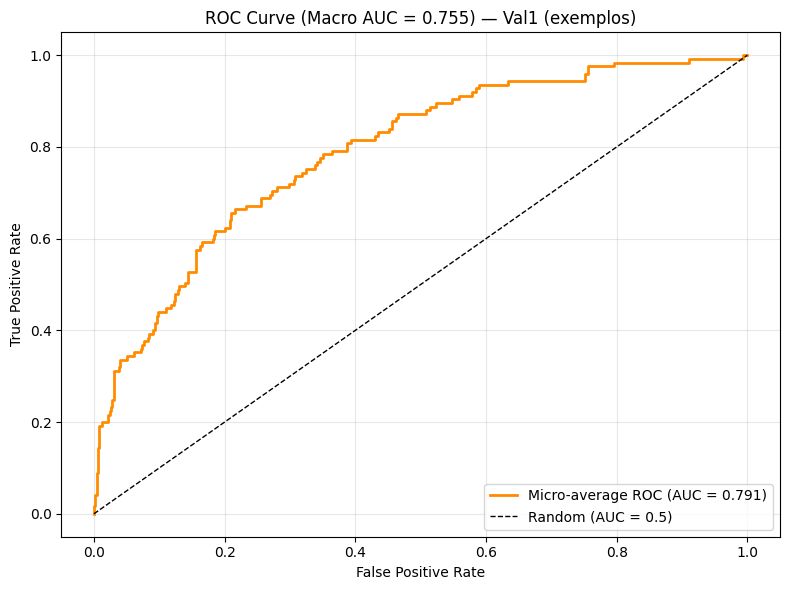

Val1 (exemplos): Micro AUC = 0.7908, Macro AUC = 0.7550


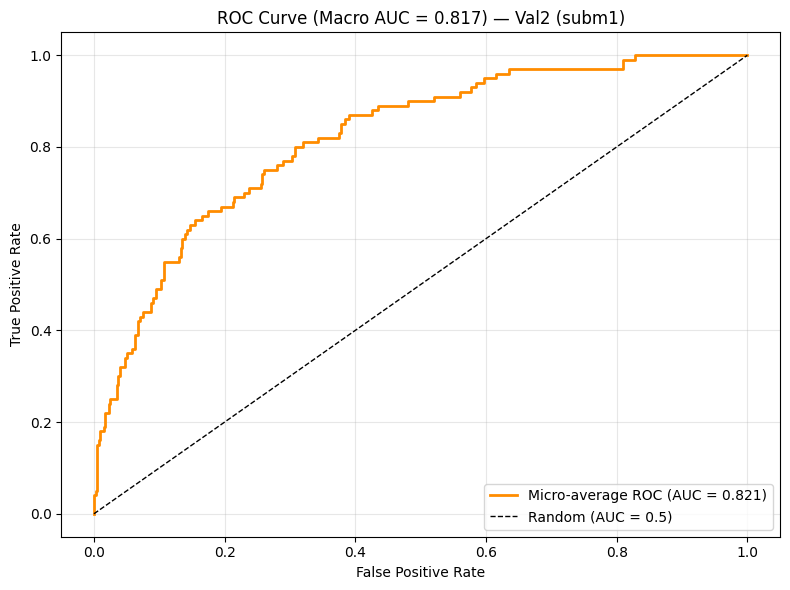

Val2 (subm1): Micro AUC = 0.8205, Macro AUC = 0.8173


In [11]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))

    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc


macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')


## 7. Conclusões

In [12]:
print('=' * 60)
print('CONCLUSÕES — CNN1D')
print('=' * 60)
print()

print('Média por dimensão de embedding:')
for emb in sorted(results_df['embedding_dim'].unique()):
    mask = results_df['embedding_dim'] == emb
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  emb={emb}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["internal_val"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

os.makedirs(os.path.join(ROOT, 'saved_models'), exist_ok=True)
results_path = os.path.join(ROOT, 'data', 'processed', 'cnn1d_results.csv')
results_df.to_csv(results_path, index=False)
best_vocab.save(os.path.join(ROOT, 'saved_models', 'vocab_cnn.pkl'))
torch.save(best_model.state_dict(), os.path.join(ROOT, 'saved_models', 'cnn1d_final.pth'))
print(f'Resultados guardados em {results_path}')
print('Modelo e vocabulário guardados em saved_models/')


CONCLUSÕES — CNN1D

Média por dimensão de embedding:
  emb=50: val1=0.4813 | val2=0.5467
  emb=100: val1=0.4691 | val2=0.5229

Melhor configuração:
  vocab_size: 1000
  embedding_dim: 100
  n_filters: 64
  filter_sizes: [2, 3]
  dropout: 0.2
  lr: 0.001
  batch_size: 32
  epochs: 30
Best Internal Validation Accuracy: 0.9494
Val1 AUC (macro): 0.7550
Val2 Accuracy: 0.5500
Val2 AUC (macro): 0.8173
Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/data/processed/cnn1d_results.csv
Modelo e vocabulário guardados em saved_models/
